In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [22]:
# https://scikit-learn.org/stable/developers/develop.html
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.tree import DecisionTreeRegressor
from sklearn.base import is_classifier, is_regressor


In [23]:
# https://scikit-learn.org/stable/developers/develop.html
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.tree import DecisionTreeRegressor
from sklearn.base import is_classifier, is_regressor

class HierarchicalEnsembleRegressor(RegressorMixin, BaseEstimator):
    def __init__(self, main_model, submodels, bin_overlap=0.0):
        self.main_model = main_model
        self.submodels = submodels
        self.bin_overlap = bin_overlap
        
    def fit(self, X, y):
        X = X.values if hasattr(X, "values") else np.array(X)
        y = y.values if hasattr(y, "values") else np.array(y)

        self.y_min = np.min(y)
        self.y_max = np.max(y)
        X_bins, y_bins = self.get_bins(X, y)

        for i, c in enumerate(zip(X_bins, y_bins)):
            X_bin, y_bin = c
            self.submodels[i].fit(X_bin, y_bin)

        if is_classifier(self.main_model):
            y_bin = self.target_to_bin(y)
            self.main_model.fit(X, y_bin)
        elif is_regressor(self.main_model):
            self.main_model.fit(X, y)
        else:
            #raise ValueError("main_model is neither a recognized classifier nor a regressor!")
            y_bin = self.target_to_bin(y)
            self.main_model.fit(X, y_bin)
    
    def predict__(self, X):
        X = X.values if hasattr(X, "values") else np.array(X)

        y_bin_pred = self.predict_bin(X)
        final_pred = np.zeros(len(X))
    
        for i in range(len(self.submodels)):
            mask = (y_bin_pred == i)
            if np.any(mask):
                final_pred[mask] = self.submodels[i].predict(X[mask])
            
        return final_pred

    def predict(self, X):
        X = X.values if hasattr(X, "values") else np.array(X)

        # Check if the router can output probabilities (Soft Routing)
        if is_classifier(self.main_model) and hasattr(self.main_model, "predict_proba"):
            # Get the probability matrix: shape (n_samples, n_bins)
            probs = self.main_model.predict_proba(X) 
            final_pred = np.zeros(len(X))
            
            # Ask every submodel to predict the whole dataset
            for i in range(len(self.submodels)):
                sub_pred = self.submodels[i].predict(X)
                # Multiply the submodel's prediction by the classifier's confidence in that bin
                final_pred += probs[:, i] * sub_pred
                
            return final_pred
            
        else:
            # Fallback to your original Hard Routing logic
            y_bin_pred = self.predict_bin(X)
            final_pred = np.zeros(len(X))
        
            for i in range(len(self.submodels)):
                mask = (y_bin_pred == i)
                if np.any(mask):
                    final_pred[mask] = self.submodels[i].predict(X[mask])
                
            return final_pred

    def predict_bin(self, X):
        if is_classifier(self.main_model):
            return self.main_model.predict(X)
        elif is_regressor(self.main_model):
            y_pred = self.main_model.predict(X)
            return self.target_to_bin(y_pred)
        else:
            #raise ValueError("main_model is neither a recognized classifier nor a regressor!")
            return self.main_model.predict(X)
    
    def get_bins(self, X, y):
        X = X.values if hasattr(X, "values") else np.array(X)
        y = y.values if hasattr(y, "values") else np.array(y)
        N = len(self.submodels)
        width = (self.y_max - self.y_min) / N
    
        i_max = np.floor(((y - self.y_min) + self.bin_overlap) / width).astype(int)
        i_min = np.ceil(((y - self.y_min) - width - self.bin_overlap) / width).astype(int)
        i_min = np.clip(i_min, 0, N - 1)
        i_max = np.clip(i_max, 0, N - 1)
        
        X_bins = [[] for _ in range(N)]
        y_bins = [[] for _ in range(N)]
        
        for j in range(len(y)):
            for b in range(i_min[j], i_max[j] + 1):
                X_bins[b].append(X[j])
                y_bins[b].append(y[j])
    
        X_bins = [np.array(b) for b in X_bins]
        y_bins = [np.array(b) for b in y_bins]
        
        return X_bins, y_bins

    def target_to_bin(self, y):
        N = len(self.submodels)
        width = (self.y_max - self.y_min) / N
        bins = np.floor((y - self.y_min) / width).astype(int)
        return np.clip(bins, 0, N - 1)
        

In [24]:
df = pd.read_csv("training_data_02_01.csv")
#df

In [28]:
for c in df.columns:
    print(c)

PuzzleId
FEN
Moves
Rating
RatingDeviation
Popularity
NbPlays
Themes
GameUrl
OpeningTags
success_prob_rapid_1050
success_prob_rapid_1150
success_prob_rapid_1250
success_prob_rapid_1350
success_prob_rapid_1450
success_prob_rapid_1550
success_prob_rapid_1650
success_prob_rapid_1750
success_prob_rapid_1850
success_prob_rapid_1950
success_prob_rapid_2050
success_prob_blitz_1050
success_prob_blitz_1150
success_prob_blitz_1250
success_prob_blitz_1350
success_prob_blitz_1450
success_prob_blitz_1550
success_prob_blitz_1650
success_prob_blitz_1750
success_prob_blitz_1850
success_prob_blitz_1950
success_prob_blitz_2050


In [26]:
for c in df.select_dtypes(exclude=["int", "float"]).columns:
    print(c)

PuzzleId
FEN
Moves
Themes
GameUrl
OpeningTags


In [34]:
remove_attributes = []
#for c in df["themes"]:
#    remove_attributes.extend(c.split(" "))
y = df["Rating"]
#X = df.drop(columns=["themes", "solution", "epd", "rating_dev", "rating"] + remove_attributes)
X = df.drop(columns=["PuzzleId", "FEN", "Moves", "Moves", "Themes", "GameUrl", "OpeningTags", "RatingDeviation", "NbPlays", "Rating"] + remove_attributes)

In [35]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=67)
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(3645600, 23)
(3645600,)
(911400, 23)
(911400,)


In [36]:
from sklearn.preprocessing import PowerTransformer
pt = PowerTransformer(method="yeo-johnson")
y_train_transformed = pt.fit_transform(y_train.to_numpy().reshape(-1, 1)).flatten()

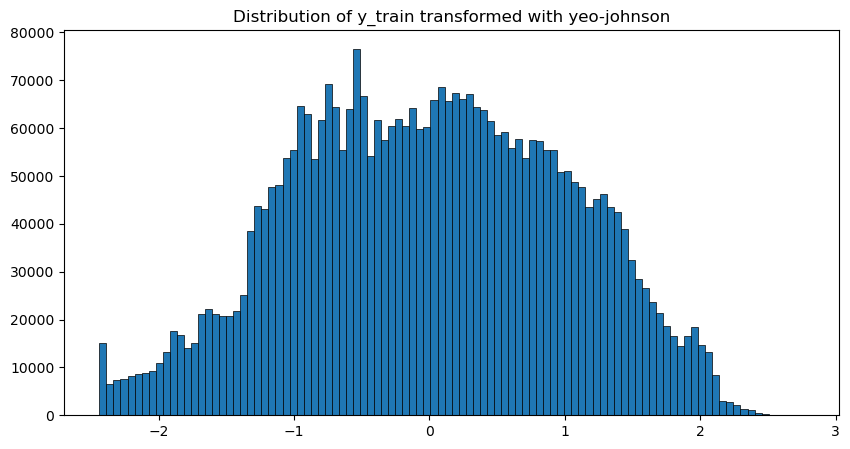

In [37]:
plt.figure(figsize=(10,5))
plt.hist(y_train_transformed, bins=100, edgecolor="black", linewidth=0.5)
plt.title("Distribution of y_train transformed with yeo-johnson")
plt.show()

In [38]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.compose import TransformedTargetRegressor
from sklearn.preprocessing import PowerTransformer
from sklearn.preprocessing import QuantileTransformer

def create_pipeline(model, y_transformer=None, steps=[]):
    target_pipeline = TransformedTargetRegressor(
        regressor=model,
        transformer=y_transformer)

    final_pipeline = Pipeline(steps=steps + [("model", target_pipeline)])

    return final_pipeline

def train(pipeline, X_train, y_train):
    pipeline.fit(X_train, y_train)

from sklearn.metrics import mean_absolute_error as MAE
y_min = np.min(y_train)
y_max = np.max(y_train)
def NMAE(y_test, y_pred):
    return MAE(y_test, y_pred)/(y_max - y_min)

def test(pipeline, X_test, y_test, metric=MAE):
    y_pred = pipeline.predict(X_test)
    return metric(y_test, y_pred)

def evaluate(model, X_train, y_train, X_test, y_test, metric=MAE, y_transformer=None, steps=[]):
    pipeline = create_pipeline(model, y_transformer=y_transformer, steps=steps)
    train(pipeline, X_train, y_train)
    return test(pipeline, X_test, y_test, metric=metric)

In [10]:
from xgboost import XGBRegressor
bins = 4
main_model = XGBRegressor(n_estimators=100, learning_rate=0.1, eval_metric="mae")
submodels = [XGBRegressor(n_estimators=100, learning_rate=0.1, eval_metric="mae") for _ in range(bins)]

In [11]:
from xgboost import XGBClassifier
bins = 4
main_model = XGBClassifier(n_estimators=100, learning_rate=0.1, eval_metric="mlogloss")
submodels = [XGBRegressor(n_estimators=100, learning_rate=0.1, eval_metric="mae") for _ in range(bins)]

In [12]:
#evaluate(main_model, X_train, y_train, X_test, y_test)

In [39]:
#model = HierarchicalEnsembleRegressor(main_model, submodels, bin_overlap=0.2)
model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    eval_metric="mae"
)

In [40]:
y_transformer = PowerTransformer(method="yeo-johnson")
#y_transformer = QuantileTransformer(output_distribution="uniform")

steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())]

In [41]:
evaluate(model, X_train, y_train, X_test, y_test)

282.19460566634746

In [16]:
#evaluate(model, X_train, y_train, X_test, y_test, y_transformer=y_transformer)

In [17]:
#evaluate(model, X_train, y_train, X_test, y_test, steps=steps)

In [18]:
#evaluate(model, X_train, y_train, X_test, y_test, y_transformer=y_transformer, steps=steps)

In [8]:
import numpy as np
from sklearn.metrics import mean_absolute_error as MAE
from sklearn.model_selection import train_test_split

# Import the Holy Trinity of Gradient Boosting
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

# Import the Stacking wrapper and our Meta-Learner
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import Ridge

# 1. Define the Base Models (Level 1)
# We are upgrading from the default 100 trees to 500, and lowering the learning rate
# so the models learn deeper, more intricate patterns in the 40 features.
base_models = [
    ('xgb', XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=8, random_state=67, n_jobs=-1)),
    ('lgbm', LGBMRegressor(n_estimators=500, learning_rate=0.05, max_depth=8, random_state=67, n_jobs=-1)),
    ('cat', CatBoostRegressor(n_estimators=500, learning_rate=0.05, depth=8, random_state=67, verbose=False))
]

# 2. Define the Meta-Learner (Level 2)
# Ridge regression is perfect here. It will look at the 3 predictions from the base models
# and figure out the mathematically optimal way to average them together.
meta_model = Ridge(alpha=1.0)

# 3. Assemble the Stacking Regressor
stacking_pipeline = StackingRegressor(
    estimators=base_models,
    final_estimator=meta_model,
    cv=5, # Uses 5-fold cross-validation to train the meta-learner safely
    n_jobs=-1
)

# 4. Train the Ultimate Architecture
print("Training Stacking Regressor... (This will take a few minutes)")
stacking_pipeline.fit(X_train, y_train)

# 5. Evaluate
y_pred = stacking_pipeline.predict(X_test)
final_mae = MAE(y_test, y_pred)

print(f"Final Stacking MAE: {final_mae:.2f}")

Training Stacking Regressor... (This will take a few minutes)
Final Stacking MAE: 364.01


In [42]:
def elo_to_difficulty(y, N=3):
    y_min = np.min(y)
    y_max = np.max(y)
    
    width = (y_max - y_min) / N
    bins = np.floor((y - y_min) / width).astype(int)
    return np.clip(bins, 0, N - 1)

In [51]:
y_train_d = elo_to_difficulty(y_train)
y_test_d = elo_to_difficulty(y_test)

In [ ]:
y_pred_d = elo_to_difficulty(y_pred)

In [52]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
acc = accuracy_score(y_test_d, y_pred_d)
print(f"Router Accuracy: {acc:.2%}")

print(classification_report(y_test_d, y_pred_d))

Router Accuracy: 71.44%
              precision    recall  f1-score   support

           0       0.77      0.73      0.75    397831
           1       0.68      0.78      0.73    437744
           2       0.62      0.22      0.32     75825

    accuracy                           0.71    911400
   macro avg       0.69      0.58      0.60    911400
weighted avg       0.71      0.71      0.70    911400



In [49]:
from xgboost import XGBClassifier
model = XGBClassifier(n_estimators=100, learning_rate=0.1, eval_metric="mlogloss")

In [50]:
model.fit(X_train, y_train_d)
y_pred_d = model.predict(X_test)

In [19]:
acc = accuracy_score(y_test_d, y_pred_d)
print(f"Router Accuracy: {acc:.2%}")

print(classification_report(y_test_d, y_pred_d))

Router Accuracy: 64.88%
              precision    recall  f1-score   support

           0       0.74      0.65      0.69     12429
           1       0.59      0.78      0.67     13678
           2       0.58      0.16      0.25      3609

    accuracy                           0.65     29716
   macro avg       0.64      0.53      0.54     29716
weighted avg       0.66      0.65      0.63     29716



In [54]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
from sklearn.neural_network import MLPClassifier
clf = MLPClassifier(
    hidden_layer_sizes=(512, 256, 128, 64, 32),
    activation='relu',
    solver='adam',
    batch_size=512,
    early_stopping=True,
    max_iter=300,
    random_state=42,
    alpha=0.001
)

print("Training started...")
clf.fit(X_train_scaled, y_train_d)
print(f"Training finished in {clf.n_iter_} epochs.")

Training started...


In [ ]:
y_pred_d = clf.predict(X_test_scaled)
acc = accuracy_score(y_test_d, y_pred_d)
print(f"Router Accuracy: {acc:.2%}")

print(classification_report(y_test_d, y_pred_d))

In [34]:
accuracy = clf.score(X_test_scaled, y_test)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

Test Accuracy: 0.00%
